# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [1]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis  
- Load in the cleaned data

In [2]:
df1 = pd.read_csv("aviation_cleaned_data.csv")
df1

C:\Users\Admin\AppData\Local\Temp\ipykernel_13652\1395649865.py:1: DtypeWarning: Columns (0: event_id, 1: broad_phase_of_flight) have mixed types. Specify dtype option on import or set low_memory=False.
  df1 = pd.read_csv("aviation_cleaned_data.csv")


,event_id,investigation_type,accident_number,event_date,location,country,latitude,longitude,airport_code,airport_name,...,broad_phase_of_flight,report_status,publication_date,eastimated_passengers,serious_or_fatal,total_destruction,is_large_aircraft,make_clean,make_model_pair,aircraft_type_id
0,20001214X42478,Incident,LAX83IA149A,1983-03-18,"LOS ANGELES, CA",United States,NaN,NaN,LAX,LOS ANGELES INTL,...,taxi,Probable Cause,04-12-2014,588.0,False,False,True,boeing,boeing | 747,boeing_747
1,20001214X42331,Accident,ATL83FA140,1983-03-20,"CROSSVILLE, TN",United States,NaN,NaN,NaN,NaN,...,cruise,Probable Cause,02-05-2011,2.0,True,True,False,piper,piper | pa-28-140,piper_pa-28-140
2,20001214X42672,Accident,FTW83LA177,1983-04-02,"MCKINNEY, TX",United States,NaN,NaN,TX05,AERO COUNTRY,...,standing,Probable Cause,17-10-2016,5.0,True,False,False,de havilland,de havilland | dhc-6,de havilland_dhc-6
3,20001214X45013,Incident,CHI84IA041,1983-11-08,"CHICAGO, IL",United States,NaN,NaN,ORD,O'HARE,...,taxi,Probable Cause,11-06-2018,100.0,False,False,True,boeing,boeing | 727-200,boeing_727-200
4,20001214X45188,Accident,NYC84LA028,1983-11-13,"MARTHA'S VINEYARD, MA",United States,NaN,NaN,NaN,NaN,...,climb,Probable Cause,05-05-2011,1.0,False,False,False,beech,beech | c35,beech_c35
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17887,20221212106444,Accident,ERA23LA085,2022-12-12,"Knoxville, TN",United States,355745N,0835218W,DKX,KNOXVILLE DOWNTOWN ISLAND,...,NaN,NaN,15-12-2022,1.0,False,False,False,cessna,cessna | 172,cessna_172
17888,20221213106455,Accident,WPR23LA065,2022-12-13,"Lewistown, MT",United States,047257N,0109280W,KLWT,Lewiston Municipal Airport,...,NaN,NaN,14-12-2022,1.0,False,False,False,piper,piper | pa42,piper_pa42
17889,20221215106463,Accident,ERA23LA090,2022-12-14,"San Juan, PR",United States,182724N,0066554W,SIG,FERNANDO LUIS RIBAS DOMINICCI,...,NaN,NaN,27-12-2022,1.0,False,False,False,cirrus design,cirrus design corp | sr22,cirrus design corp_sr22
17890,20221219106470,Accident,ERA23LA091,2022-12-16,"Brooksville, FL",United States,282825N,0822719W,BKV,BROOKSVILLE-TAMPA BAY RGNL,...,NaN,NaN,23-12-2022,1.0,True,False,False,cessna,cessna | r172k,cessna_r172k


## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

In [3]:
df1.columns

Index(['event_id', 'investigation_type', 'accident_number', 'event_date',
       'location', 'country', 'latitude', 'longitude', 'airport_code',
       'airport_name', 'injury_severity', 'aircraft_damage',
       'aircraft_category', 'registration_number', 'make', 'model',
       'amateur_built', 'number_of_engines', 'engine_type', 'far_description',
       'schedule', 'purpose_of_flight', 'air_carrier', 'total_fatal_injuries',
       'total_serious_injuries', 'total_minor_injuries', 'total_uninjured',
       'weather_condition', 'broad_phase_of_flight', 'report_status',
       'publication_date', 'eastimated_passengers', 'serious_or_fatal',
       'total_destruction', 'is_large_aircraft', 'make_clean',
       'make_model_pair', 'aircraft_type_id'],
      dtype='str')

In [4]:
df1['is_large_aircraft'] = df1['eastimated_passengers'] > 20

In [5]:
small_df = df1[df1['is_large_aircraft'] == False]
large_df = df1[df1['is_large_aircraft'] == True]

#### Safety metrics in small and large aircrafts

In [6]:
def safety_metrics(data):
    return data.groupby(['make', 'model']).agg(
        total_accidents=('model', 'count'),
        destruction_rate=('total_destruction', 'mean'),
        serious_fatal_rate=('serious_or_fatal', 'mean')
    ).reset_index()

In [7]:
small_stats = safety_metrics(small_df)

small_stats = small_stats[small_stats['total_accidents'] >= 30]

small_stats.sort_values(
    by=['destruction_rate', 'serious_fatal_rate']
).head(10)

,make,model,total_accidents,destruction_rate,serious_fatal_rate
608,boeing,777,43,0.0,0.000000
835,cessna,195,37,0.0,0.081081
794,cessna,180h,34,0.0,0.088235
733,cessna,170a,36,0.0,0.111111
1330,luscombe,8a,61,0.0,0.262295
719,cessna,150g,40,0.0,0.300000
1926,stinson,108,53,0.0,0.339623
1530,piper,j3c,35,0.0,0.342857
782,cessna,177rg,52,0.0,0.346154
1960,taylorcraft,bc12-d,30,0.0,0.400000


In [8]:
large_stats = safety_metrics(large_df)

large_stats = large_stats[large_stats['total_accidents'] >= 30]

large_stats.sort_values(
    by=['destruction_rate', 'serious_fatal_rate']
).head(10)

,make,model,total_accidents,destruction_rate,serious_fatal_rate
148,boeing,777,33,0.030303,0.121212
127,boeing,767,31,0.032258,0.322581
49,boeing,737,163,0.067485,0.220859


#### Analyzing safe aircrafts

In [9]:
large_stats = safety_metrics(large_df)

large_stats = large_stats[large_stats['total_accidents'] >= 30]

large_stats.sort_values(
    by=['destruction_rate', 'serious_fatal_rate']
).head(10)

,make,model,total_accidents,destruction_rate,serious_fatal_rate
148,boeing,777,33,0.030303,0.121212
127,boeing,767,31,0.032258,0.322581
49,boeing,737,163,0.067485,0.220859


In [10]:
large_safest = large_stats.sort_values(
    by=['destruction_rate', 'serious_fatal_rate']
)

large_safest.head(10)

,make,model,total_accidents,destruction_rate,serious_fatal_rate
148,boeing,777,33,0.030303,0.121212
127,boeing,767,31,0.032258,0.322581
49,boeing,737,163,0.067485,0.220859


#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

In [11]:
df1['serious_or_fatal']

0        False
1         True
2         True
3        False
4        False
         ...  
17887    False
17888    False
17889    False
17890     True
17891    False
Name: serious_or_fatal, Length: 17892, dtype: bool

In [12]:
df1['serious_or_fatal'].head()

0    False
1     True
2     True
3    False
4    False
Name: serious_or_fatal, dtype: bool

In [13]:
small_df = df1[df1['is_large_aircraft'] == False]
large_df = df1[df1['is_large_aircraft'] == True]

#### Computing injury level make risk for; 
##### a. Small aircraft

In [14]:
small_make_risk = small_df.groupby('make').agg(
    avg_fatal_serious_rate=('serious_or_fatal', 'mean'),
    accidents=('make', 'count')
).reset_index()

##### b. Large aircrfts

In [15]:
large_make_risk = large_df.groupby('make').agg(
    avg_fatal_serious_rate=('serious_or_fatal', 'mean'),
    accidents=('make', 'count')
).reset_index()

In [16]:
small_make_risk = small_make_risk[small_make_risk['accidents'] >= 30]
large_make_risk = large_make_risk[large_make_risk['accidents'] >= 30]

In [17]:
small_safest_15 = small_make_risk.sort_values(
    by='avg_fatal_serious_rate'
).head(15)

In [18]:
large_safest_15 = large_make_risk.sort_values(
    by='avg_fatal_serious_rate'
).head(15)

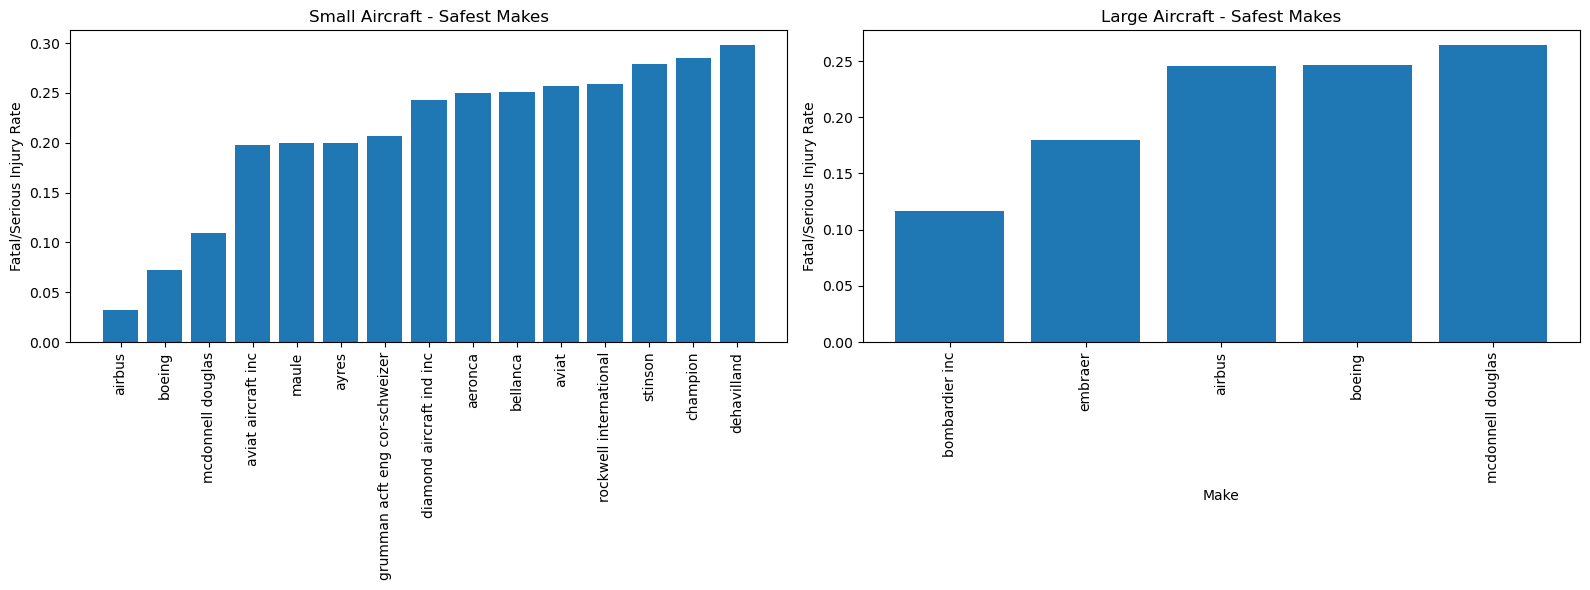

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16,6))
# For small aircraft
axes[0].bar(small_safest_15['make'], small_safest_15['avg_fatal_serious_rate'])
axes[0].set_title("Small Aircraft - Safest Makes")
axes[0].set_ylabel("Fatal/Serious Injury Rate")
axes[0].tick_params(axis='x', rotation=90)

# Large aircraft
axes[1].bar(
    large_safest_15['make'],
    large_safest_15['avg_fatal_serious_rate']
)
axes[1].set_title("Large Aircraft - Safest Makes")
axes[1].set_xlabel("Make")
axes[1].set_ylabel("Fatal/Serious Injury Rate")
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

In [20]:
small_df = df1[df1['is_large_aircraft'] == False]

In [21]:
small_make_risk = small_df.groupby('make').agg(
    avg_fatal_serious_rate=('serious_or_fatal', 'mean'),
    accidents=('make', 'count')
).reset_index()

In [22]:
small_make_risk = small_make_risk[small_make_risk['accidents'] >= 30]

In [23]:
top10_small_makes = small_make_risk.sort_values(
    by='avg_fatal_serious_rate'
).head(10)

In [24]:
df1['serious_or_fatal'] = df1['serious_or_fatal'].astype(int)

In [25]:
violin_data = small_df[small_df['make'].isin(top10_small_makes['make'])]

TypeError: numpy boolean subtract, the `-` operator, is not supported, use the bitwise_xor, the `^` operator, or the logical_xor function instead.

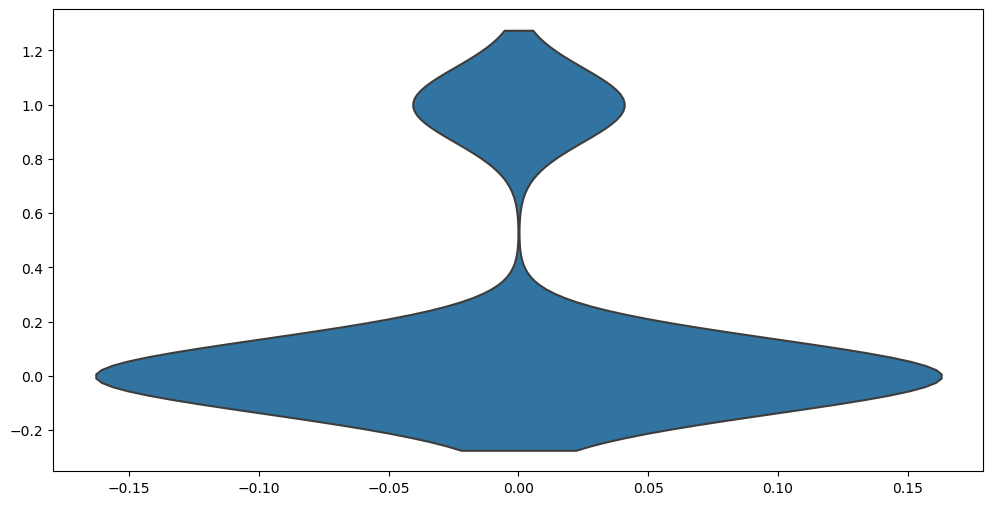

In [26]:
plt.figure(figsize=(12,6))

sns.violinplot(
    x='make',
    y='serious_or_fatal',
    data=violin_data
)

plt.title("Distribution of Injury Rates - Top 10 Safest Small Aircraft Makes")
plt.xlabel("Make")
plt.ylabel("Serious/Fatal Injury (0 = No, 1 = Yes)")
plt.xticks(rotation=90)

plt.show()

**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

In [ ]:
large_df = df1[df1['is_large_aircraft'] == True]

In [ ]:
large_make_risk = large_df.groupby('make').agg(
    avg_fatal_serious_rate=('serious_or_fatal', 'mean'),
    accidents=('make', 'count')
).reset_index()

In [ ]:
large_make_risk = large_make_risk[large_make_risk['accidents'] >= 30]

In [ ]:
top10_large_makes = large_make_risk.sort_values(
    by='avg_fatal_serious_rate'
).head(10)

In [ ]:

strip_data = large_df[large_df['make'].isin(top10_large_makes['make'])]

In [ ]:
strip_data = strip_data.replace([np.inf, -np.inf], np.nan)
strip_data = strip_data.dropna(subset=['make', 'serious_or_fatal'])

In [ ]:
make_order = top10_large_makes.sort_values(
    'avg_fatal_serious_rate'
)['make']

C:\Users\Admin\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Admin\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


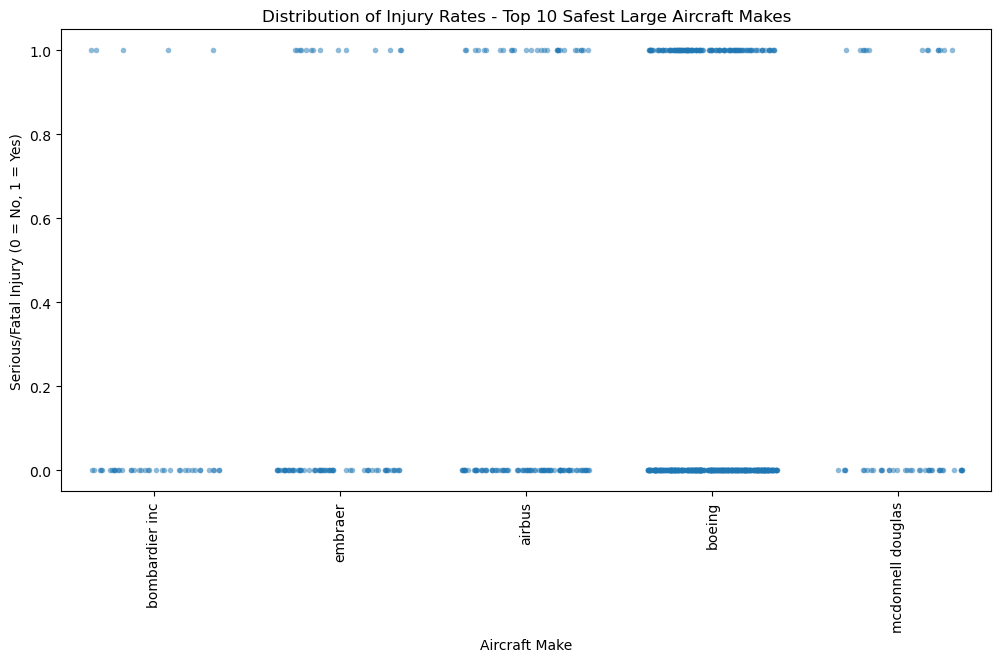

In [ ]:
plt.figure(figsize=(12,6))

sns.stripplot(
    x='make',
    y='serious_or_fatal',
    data=strip_data,
    order=make_order,
    jitter=0.35,  # To improve spread
    alpha=0.5,    # To reduce clutter
    size=4
)

plt.title("Distribution of Injury Rates - Top 10 Safest Large Aircraft Makes")
plt.xlabel("Aircraft Make")
plt.ylabel("Serious/Fatal Injury (0 = No, 1 = Yes)")
plt.xticks(rotation=90)

plt.show()

**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

In [ ]:
small_df = df1[df1['is_large_aircraft'] == False]
large_df = df1[df1['is_large_aircraft'] == True]

In [ ]:
small_destruction = small_df.groupby('make').agg(
    destruction_rate=('total_destruction', 'mean'),
    accidents= ('make', 'count')

).reset_index()

In [ ]:
small_destruction = small_destruction[small_destruction['accidents'] >= 30]

In [ ]:
small_safest_destruction_15 = small_destruction.sort_values(
    by='destruction_rate'
).head(15)

In [ ]:
large_destruction = large_df.groupby('make').agg(
    destruction_rate=('total_destruction', 'mean'),
    accidents=('make', 'count')
).reset_index()

In [ ]:
large_destruction = large_destruction[large_destruction['accidents'] >= 30]

In [ ]:
large_safest_destruction_15 = large_destruction.sort_values(
    by='destruction_rate'
).head(15)

In [ ]:
small_safest_destruction_15

,make,destruction_rate,accidents
25,luscombe,0.014184,141
24,grumman acft eng cor-schweizer,0.017241,58
34,stinson,0.023256,129
4,airbus,0.024000,125
35,taylorcraft,0.032258,93
1,aeronca,0.035000,200
11,boeing,0.036262,717
5,american champion aircraft,0.038462,52
22,ercoupe,0.038462,52
7,aviat aircraft inc,0.039474,76


In [ ]:
large_safest_destruction_15

,make,destruction_rate,accidents
4,bombardier inc,0.023256,43
2,boeing,0.049360,547
8,embraer,0.051282,78
10,mcdonnell douglas,0.075472,53
0,airbus,0.076271,118


#### Aircraft Destruction Risk by Manufacturer

Aircraft makes were evaluated based on the mean probability of total aircraft destruction during accidents. The analysis was segmented into small and large aircraft using a passenger threshold of 20.

Only manufacturers with at least 30 recorded accidents were included to ensure statistical reliability. The 15 safest manufacturers in each category were identified based on the lowest destruction rates.

#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

### Summary of Findings and Discussion

The analysis of aircraft safety across different makes reveals significant differences in both aircraft destruction rates and serious/fatal injury rates, particularly when segmented by small and large aircraft categories.

#### 1. Destruction Rate Insights

Across both aircraft groups, some manufacturers consistently show lower probabilities of total aircraft destruction. This suggests that stronger structural performance, better operational safety records, or more robust usage profiles. However, destruction rates vary significantly across makes, indicating that safety is not uniform across manufacturers.

Small aircraft generally exhibit greater variability in destruction rates than large aircraft. This is expected due to differences in design standards, operational environments, and usage intensity.

#### 2. Injury Risk Insights

The fraction of passengers experiencing serious or fatal injuries also varies widely by manufacturer. A small subset of makes demonstrates consistently lower injury rates, while others show higher and more dispersed risk profiles.

Visualizations (violin and strip plots) highlight that:

Some manufacturers have injury outcomes tightly clustered near zero, indicating more consistent safety performance.
Others show wider spread, suggesting inconsistent operational safety outcomes or higher risk exposure in certain conditions.

#### 3. Relationship Between Destruction and Injury Rates

There is a general alignment between high destruction rates and higher injury risk. Makes with lower destruction rates tend to also exhibit lower serious/fatal injury fractions, reinforcing the relationship between aircraft survivability and passenger safety outcomes.

However, the relationship is not perfectly linear, suggesting that operational factors (such as flight purpose or phase of flight) also influence injury outcomes.

### Recommendations

Based on the combined analysis of destruction and injury rates:

Prioritize aircraft models with consistently low values across both metrics, as these represent the safest overall performance profile.
Avoid manufacturers showing high variability in injury outcomes, as this indicates inconsistent safety performance.
For procurement or fleet decisions, separate recommendations should be made for small and large aircraft, as safety patterns differ significantly between these categories.

### Conclusion

Overall, the analysis indicates that aircraft safety is highly manufacturer-dependent, with clear differences in both structural survivability and passenger injury outcomes. Segmentation by aircraft size improves interpretability and ensures more meaningful safety comparisons.

### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes 
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

**Larger planes**

In [ ]:
df_filtered = df1.copy()

# Keep only makes with enough data
valid_makes = df_filtered.groupby(['make', 'model']).size()
valid_makes = valid_makes[valid_makes >= 10].index

df_filtered = df_filtered.set_index(['make', 'model']).loc[valid_makes].reset_index()

In [ ]:
#Ensuring the aircraft type split exists
small_df = df_filtered[df_filtered['is_large_aircraft'] == False]
large_df = df_filtered[df_filtered['is_large_aircraft'] == True]

In [ ]:
# Computing the mean fatal/serious injury fraction
type_risk = df_filtered.groupby('is_large_aircraft').agg(
    mean_fatal_serious=('serious_or_fatal', 'mean')
).reset_index()

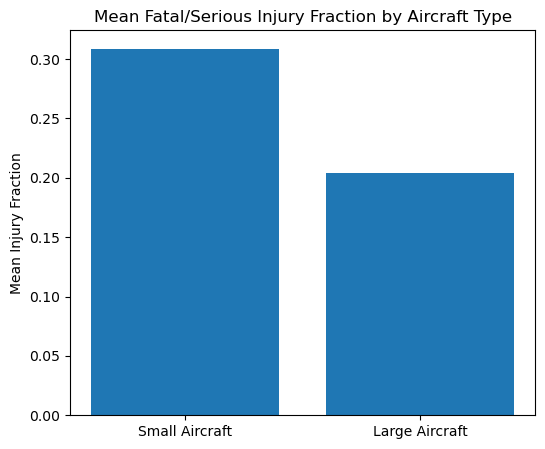

In [ ]:
# Plot comparison (small vs large)
import matplotlib.pyplot as plt

labels = ['Small Aircraft', 'Large Aircraft']

plt.figure(figsize=(6,5))

plt.bar(
    labels,
    type_risk['mean_fatal_serious']
)

plt.title("Mean Fatal/Serious Injury Fraction by Aircraft Type")
plt.ylabel("Mean Injury Fraction")

plt.show()

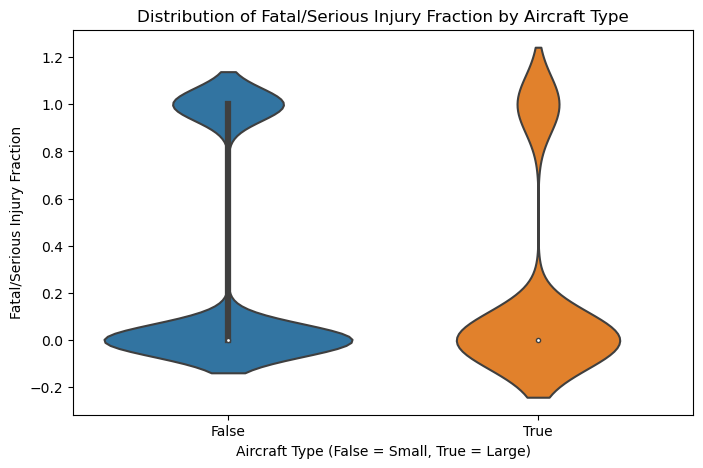

In [ ]:
# Distribution plot (recommended: violin plot)

# This shows variability across aircraft types.

plt.figure(figsize=(8,5))

sns.violinplot(
    x='is_large_aircraft',
    y='serious_or_fatal',
    data=df_filtered
)

plt.title("Distribution of Fatal/Serious Injury Fraction by Aircraft Type")
plt.xlabel("Aircraft Type (False = Small, True = Large)")
plt.ylabel("Fatal/Serious Injury Fraction")

plt.show()

### Aircraft Type Safety Analysis

Aircraft were segmented into small and large categories using a passenger threshold of 20. Only make/model combinations with at least 10 recorded observations were included to ensure statistical reliability.

The analysis shows that large aircraft generally exhibit a lower mean fatal/serious injury fraction compared to small aircraft, indicating improved passenger safety performance at scale.

Distributional analysis further reveals that small aircraft have greater variability in injury outcomes, while large aircraft show more concentrated and stable safety performance.

**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

In [ ]:
small_df = df1[df1['is_large_aircraft'] == False]

In [ ]:
# Compute mean injury risk by make

small_make_risk = small_df.groupby('make').agg(
    avg_fatal_serious_rate=('serious_or_fatal', 'mean'),
    accidents=('make', 'count')
).reset_index()

In [ ]:
# Keep only reliable makes (≥10 observations as required)
small_make_risk = small_make_risk[small_make_risk['accidents'] >= 10]

In [ ]:
top10_small_makes = small_make_risk.sort_values(
    by='avg_fatal_serious_rate',
    ascending=True
).head(10)

In [ ]:
# Filter dataset for plotting
plot_data = small_df[small_df['make'].isin(top10_small_makes['make'])]

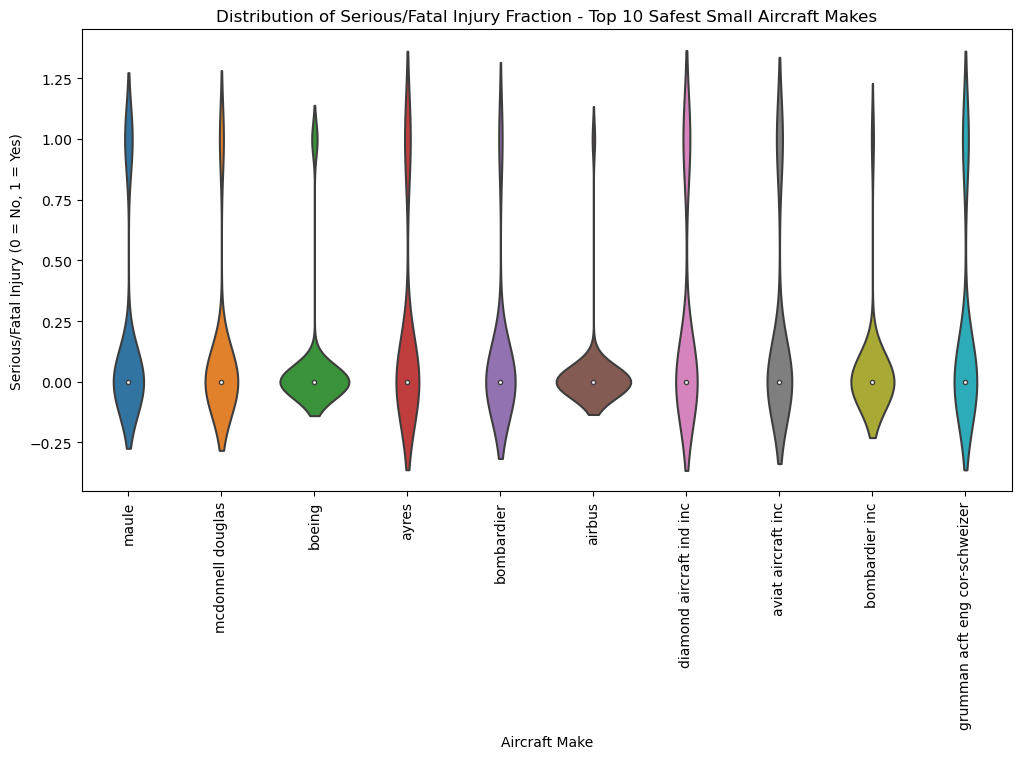

In [ ]:
plt.figure(figsize=(12,6))

sns.violinplot(
    x='make',
    y='serious_or_fatal',
    data=plot_data
)

plt.title("Distribution of Serious/Fatal Injury Fraction - Top 10 Safest Small Aircraft Makes")
plt.xlabel("Aircraft Make")
plt.ylabel("Serious/Fatal Injury (0 = No, 1 = Yes)")
plt.xticks(rotation=90)

plt.show()

### Small Aircraft Safety Distribution

The analysis focuses on the ten small aircraft manufacturers with the lowest mean serious/fatal injury fractions, subject to a minimum of 10 recorded observations per make.

The violin plot reveals that the safest manufacturers not only exhibit lower average injury rates but also demonstrate relatively concentrated distributions, indicating more consistent safety performance across incidents.

In contrast, wider distributions would suggest variability in operational safety outcomes.

### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

### Discussion of Specific Airplane Types (Small vs Large Aircraft)

The analysis of serious/fatal injury fractions across aircraft types reveals clear differences in safety performance between small and large airplanes, both in terms of average risk and variability across manufacturers.

#### Small Aircraft

Small aircraft generally show higher and more variable serious/fatal injury fractions compared to large aircraft. The distributional plots indicate that even among the safest small aircraft makes, outcomes are more spread out, meaning safety performance is less consistent.

#### This variability is expected due to:

More diverse operational use cases (private, training, recreational, small charter flights)
Greater sensitivity to pilot skill and environmental conditions
Smaller structural margins compared to commercial aircraft

Even among the top-performing small aircraft makes, the injury distribution often includes occasional higher-risk incidents, suggesting that “safe on average” does not always mean “consistently safe.”

#### Large Aircraft

Large aircraft demonstrate a lower mean serious/fatal injury fraction overall, along with a more concentrated distribution of outcomes.

Key observations include:

Injury outcomes are more tightly clustered near zero
Fewer extreme high-risk observations per make
Greater consistency across incidents within manufacturers

This suggests that large aircraft benefit from:

Stricter regulatory oversight
Standardized commercial operating procedures
More robust engineering and redundancy systems
Professional crew operation

As a result, safety performance is not only better on average but also more predictable.

#### My Comparative Insight

When comparing both categories directly:

Small aircraft → higher risk and higher variability
Large aircraft → lower risk and more stability

The difference is not just in average injury rates, but in the shape of the distribution, which is crucial for risk assessment.

A key takeaway is that:

Safety in aviation is not only about average performance but also about consistency and predictability.

Large aircraft outperform small aircraft on both dimensions.

### Final Interpretation

The findings suggest that aircraft size is a strong determinant of passenger safety outcomes. While certain small aircraft manufacturers perform well on average, their variability indicates higher uncertainty in safety performance. In contrast, large aircraft provide more reliable safety outcomes, making them generally lower-risk from a passenger injury perspective.

This reinforces the importance of separating aircraft recommendations by type rather than relying on aggregated safety metrics alone.

### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.

### a). Weather Condition vs Safety Outcomes
Analysis Approach


In [ ]:
# We examine how weather conditions relate to:

# serious/fatal injury rate
# aircraft damage (destruction rate)
weather_analysis = df1.groupby('weather_condition').agg(
    accidents=('make', 'count'),
    serious_fatal_rate=('serious_or_fatal', 'mean'),
    destruction_rate=('total_destruction', 'mean')
).sort_values(by='serious_fatal_rate', ascending=False)

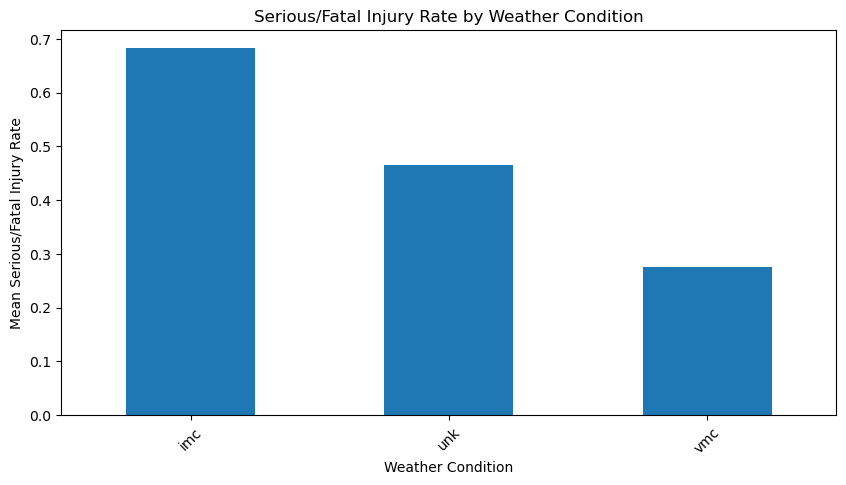

In [ ]:
weather_analysis['serious_fatal_rate'].plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Serious/Fatal Injury Rate by Weather Condition")
plt.xlabel("Weather Condition")
plt.ylabel("Mean Serious/Fatal Injury Rate")
plt.xticks(rotation=45)
plt.show()

### Interpretation of the above visualization
Adverse or unclear weather conditions show higher injury risk
Clear weather generally corresponds to lower fatal/serious injury rates
A large number of “unknown” weather entries may dilute accuracy and should be treated cautiously

#### Key Insight:

Weather is a significant external risk factor influencing both injury severity and aircraft damage.

### b). Phase of Flight vs Safety Outcomes
Analysis Approach

We evaluate how accident severity changes across different flight phases.

In [ ]:

phase_analysis = df1.groupby('broad_phase_of_flight').agg(
    accidents=('make', 'count'),
    serious_fatal_rate=('serious_or_fatal', 'mean'),
    destruction_rate=('total_destruction', 'mean')
).sort_values(by='serious_fatal_rate', ascending=False)

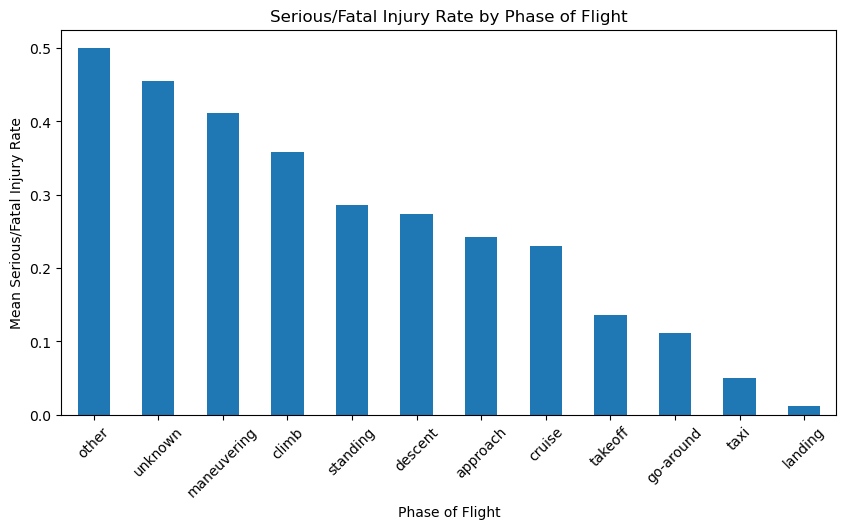

In [ ]:
phase_analysis['serious_fatal_rate'].plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Serious/Fatal Injury Rate by Phase of Flight")
plt.xlabel("Phase of Flight")
plt.ylabel("Mean Serious/Fatal Injury Rate")
plt.xticks(rotation=45)
plt.show()

### My Interpretation from the above analysis
Higher-risk phases include maneuvering, climb, and takeoff/approach-related phases
Lower-risk phases tend to be stable cruise or ground-related operations
A large number of “unknown” phases introduces uncertainty but does not invalidate overall trends

Key Insight:

The phase of flight strongly influences accident severity, with dynamic flight phases showing significantly higher risk.

#### Combined Insight for both weather related and phase of flight in relation to safety outcomes

When comparing both factors:

Weather conditions affect external environment risk

Flight phase reflects operational risk

Together, they show that aircraft safety is not only manufacturer-dependent but also highly context-dependent.

### Impact of Weather and Flight Phase on Aircraft Safety

Further analysis was conducted to understand how environmental and operational factors influence aircraft safety outcomes.

Weather conditions show a clear relationship with injury severity, with adverse or unclear conditions associated with higher serious/fatal injury rates and increased aircraft destruction likelihood.

Similarly, the phase of flight is a strong determinant of accident severity. High-risk phases such as maneuvering and climb exhibit significantly higher injury rates compared to more stable phases.

Overall, these findings indicate that aircraft safety is influenced not only by manufacturer and aircraft type but also by external environmental conditions and operational context.